In [17]:
!pip install openpyxl -q

In [18]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils import resample

In [19]:
df = pd.read_excel("/content/Last_HouseMD_DataSet.xlsx")

print(df.head())

print(df.columns)

   season  episode speaker                   Symptom Test Drug Procedure  \
0       1        1  Wilson                     nöbet  NaN  NaN       NaN   
1       1        1  Wilson                     afazi  NaN  NaN       NaN   
2       1        1  Wilson  zihinsel durum bozukluğu  NaN  NaN       NaN   
3       1        1   House                       NaN  NaN  NaN       NaN   
4       1        1  Wilson                       NaN  NaN  NaN       NaN   

     Intent diagnosis_stage Sarcasm Emotion  Organ correct_prediction  \
0  açıklama         hipotez       0    nötr  beyin  nörosistiserkozis   
1  açıklama         hipotez       0    nötr  beyin  nörosistiserkozis   
2  açıklama         hipotez       0    nötr  beyin  nörosistiserkozis   
3      şaka         hipotez       1  alaycı  beyin  nörosistiserkozis   
4  açıklama         hipotez       0    nötr  beyin  nörosistiserkozis   

  model_prediction                                               text  \
0              NaN  29 yaşında 

In [20]:
df = df.dropna(subset=["text", "Organ"])

In [21]:
df = df.drop_duplicates()

In [22]:
def temizle(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"\d+", "", text)

    text = re.sub(r"[^a-zçğıöşü\s]", "", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

df["text"] = df["text"].apply(temizle)

In [7]:
df = df[df["text"].str.len() > 5]

In [23]:
print(df["Organ"].value_counts())

Organ
beyin                588
kalp                 397
-                    326
akciğer              276
kan                  163
                    ... 
sklera, karaciğer      1
göğüs kafesi           1
Bacak kasları          1
ince bağırsak          1
Kalp, akciğerler       1
Name: count, Length: 758, dtype: int64


In [24]:
df_filtered_for_stratify = df[df["Organ"].map(df["Organ"].value_counts()) >= 25]

min_count = df_filtered_for_stratify["Organ"].value_counts().min()

balanced_df = (
    df_filtered_for_stratify.groupby("Organ", group_keys=False)
      .sample(n=min_count, random_state=42)
).reset_index(drop=True)

In [25]:
import random

def random_swap(words, n=1):
    words = list(words)
    if len(words) < 2:
        return ' '.join(words)

    new_words = words[:]
    for _ in range(n):
        idx1, idx2 = random.sample(range(len(new_words)), 2)
        new_words[idx1], new_words[idx2] = new_words[idx2], new_words[idx1]
    return ' '.join(new_words)


augmented_data = []
num_aug_per_sample = 1

for index, row in balanced_df.iterrows():
    original_text = row['text']
    original_organ = row['Organ']

    augmented_data.append({'text': original_text, 'Organ': original_organ})

    words = original_text.split()
    for _ in range(num_aug_per_sample):
        swapped_text = random_swap(words, n=2)
        augmented_data.append({'text': swapped_text, 'Organ': original_organ})

augmented_df = pd.DataFrame(augmented_data)

combined_df = pd.concat([balanced_df, augmented_df]).reset_index(drop=True)

print(f"Original balanced_df size: {len(balanced_df)}")
print(f"Augmented combined_df size: {len(combined_df)}")
print("Example of augmented text:")
print(combined_df[combined_df['text'] != balanced_df['text'].iloc[0]].iloc[0])

Original balanced_df size: 780
Augmented combined_df size: 2340
Example of augmented text:
season                                                              4.0
episode                                                            10.0
speaker                                                           House
Symptom                                                               -
Test                                                                  -
Drug                                                                  -
Procedure                                                             -
Intent                                                         Açıklama
diagnosis_stage                                           değerlendirme
Sarcasm                                                               0
Emotion                                                         Uyarıcı
Organ                                                                 -
correct_prediction                           

In [26]:
!pip install transformers -q

In [27]:
from transformers import pipeline
import random
fill_mask = pipeline(
    "fill-mask",
    model="dbmdz/bert-base-turkish-cased",
    tokenizer="dbmdz/bert-base-turkish-cased",
    device=-1
)

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [28]:
def bert_augment_text(text, num_augmentations=1, mask_percentage=0.15):
    words = text.split()
    augmented_texts = [text]

    if len(words) < 2:
        return augmented_texts

    for _ in range(num_augmentations):
        masked_words = words[:]
        num_to_mask = max(1, int(len(words) * mask_percentage))
        indices_to_mask = random.sample(range(len(words)), num_to_mask)

        for idx in indices_to_mask:
            masked_words[idx] = fill_mask.tokenizer.mask_token

        masked_sentence = " ".join(masked_words)


        try:

            filled_text = masked_sentence
            for _ in range(num_to_mask):
                if fill_mask.tokenizer.mask_token in filled_text:
                    preds = fill_mask(filled_text)
                    mask_index = filled_text.find(fill_mask.tokenizer.mask_token)
                    if preds and isinstance(preds[0], list):
                         best_token = preds[0][0]['token_str']
                    elif preds and isinstance(preds, list) and isinstance(preds[0], dict):
                         best_token = preds[0]['token_str']
                    else:
                        best_token = ""
                    filled_text = filled_text.replace(fill_mask.tokenizer.mask_token, best_token, 1)
                else:
                    break

            augmented_texts.append(filled_text)
        except Exception as e:
            print(f"Error augmenting text: {text}. Error: {e}")
            augmented_texts.append(text)

    return augmented_texts

bert_augmented_data = []
num_bert_aug_per_sample = 1

for index, row in balanced_df.iterrows():
    original_text = row['text']
    original_organ = row['Organ']

    augmented_samples = bert_augment_text(original_text, num_bert_aug_per_sample, mask_percentage=0.2)
    for aug_text in augmented_samples:
        bert_augmented_data.append({'text': aug_text, 'Organ': original_organ})

bert_combined_df = pd.DataFrame(bert_augmented_data)

print(f"Original balanced_df size: {len(balanced_df)}")
print(f"BERT Augmented combined_df size: {len(bert_combined_df)}")
print("Example of BERT augmented text:")
original_example = balanced_df['text'].iloc[0]
augmented_example = bert_combined_df[bert_combined_df['text'] != original_example].iloc[0]
print(f"Original: {original_example}")
print(f"Augmented: {augmented_example['text']}")

Original balanced_df size: 780
BERT Augmented combined_df size: 1557
Example of BERT augmented text:
Original: ölen hastalar çok düşüncesiz olabiliyor
Augmented: ölen hastalar hakkında düşüncesiz olabiliyor


In [29]:

X = bert_combined_df["text"]
y = bert_combined_df["Organ"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (1245,)
X_test shape: (312,)


In [30]:

char_vectorizer_bert_aug = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3,5),
    max_features=30000
)
X_train_tfidf = char_vectorizer_bert_aug.fit_transform(X_train)
X_test_tfidf = char_vectorizer_bert_aug.transform(X_test)

print(f"X_train_tfidf shape: {X_train_tfidf.shape}")
print(f"X_test_tfidf shape: {X_test_tfidf.shape}")

X_train_tfidf shape: (1245, 30000)
X_test_tfidf shape: (312, 30000)


In [33]:
from sklearn.linear_model import LogisticRegression

model_bert_aug = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    C=3.0
)
model_bert_aug.fit(X_train_tfidf, y_train)

print("Model training with BERT augmented data complete.")

Model training with BERT augmented data complete.


In [35]:

preds_bert_aug = model_bert_aug.predict(X_test_tfidf)

print("Accuracy (BERT Augmented):", accuracy_score(y_test, preds_bert_aug))
print("\nClassification Report (BERT Augmented):\n", classification_report(y_test, preds_bert_aug))

Accuracy (BERT Augmented): 0.8365384615384616

Classification Report (BERT Augmented):
                precision    recall  f1-score   support

            -       0.67      0.60      0.63        10
      Akciğer       1.00      0.80      0.89        10
     Bağırsak       1.00      1.00      1.00        11
        Beyin       0.85      1.00      0.92        11
       Böbrek       1.00      0.90      0.95        10
        Genel       0.75      0.82      0.78        11
         Kalp       0.71      0.91      0.80        11
          Kan       0.79      1.00      0.88        11
    Karaciğer       1.00      0.90      0.95        10
      akciğer       1.00      0.80      0.89        10
        bacak       0.92      1.00      0.96        11
     bağırsak       1.00      1.00      1.00        10
        beyin       0.83      1.00      0.91        10
       böbrek       0.75      0.90      0.82        10
         cilt       0.90      0.82      0.86        11
        damar       0.80      0

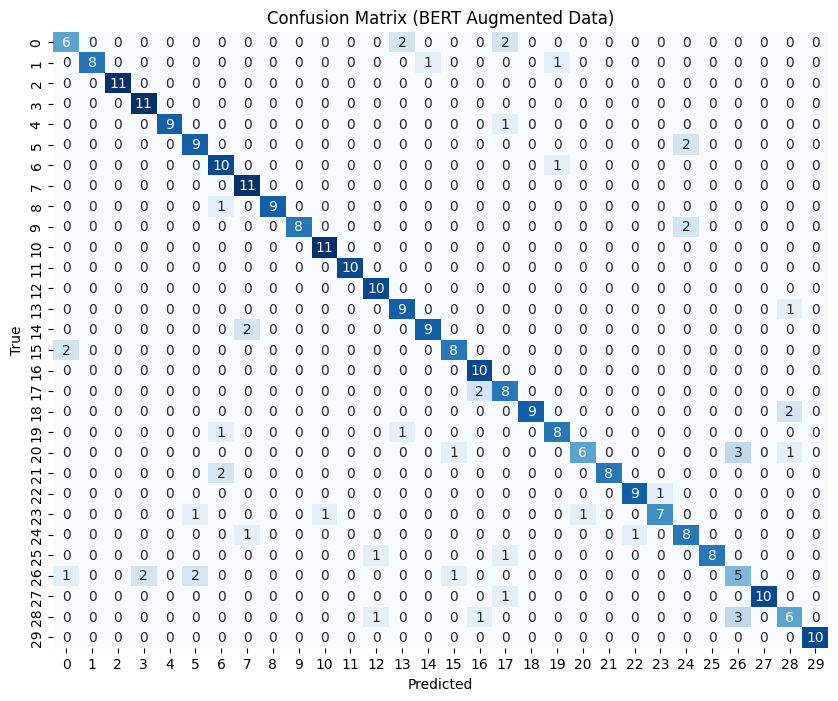

In [38]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_bert_aug = confusion_matrix(y_test, preds_bert_aug)

plt.figure(figsize=(10,8))
sns.heatmap(cm_bert_aug, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (BERT Augmented Data)')
plt.show()

In [56]:
text_for_prediction = "tansiyonum çıktı"
cleaned_text_for_prediction = temizle(text_for_prediction)

vec_for_prediction = char_vectorizer_bert_aug.transform([cleaned_text_for_prediction])
prediction_bert_aug = model_bert_aug.predict(vec_for_prediction)

print(f"Input Text: '{text_for_prediction}'")
print(f"Predicted Organ (BERT Augmented Model): {prediction_bert_aug[0]}")

Input Text: 'tansiyonum çıktı '
Predicted Organ (BERT Augmented Model): kalp
